In [71]:
# Cell 1 — imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Cell 2 — basic sine wave
Fs = 44100
numsec = 1.0
freq = 440
t = torch.linspace(0, numsec, int(Fs * numsec))
a = torch.sin(t * 2 * np.pi * 440)
print("Shape: ", a.shape)

# Cell 3 — helper functions
def sin_wav(freq, Fs, duration):
    t = torch.linspace(0, duration, int(Fs * duration))
    return torch.sin(t * 2 * np.pi * freq)

def make_phase(freq, Fs, duration):
    t = torch.linspace(0, duration, int(Fs * duration))
    return t * (2 * np.pi) * freq

def apply_phase_mod(phase, modulation):
    modulated_phase = phase + modulation
    return torch.sin(modulated_phase)

def operator(freq, Fs, duration, level, modulation=None):
    self_phase = make_phase(freq, Fs, duration)
    if modulation is None:
        modulation = torch.zeros_like(self_phase)
    return apply_phase_mod(self_phase, modulation) * level

def make_mod_matrix(values):
    mod_matrix = torch.zeros(4,4)
    mod_matrix[0][0] = values[0]
    mod_matrix[1][0] = values[1]
    mod_matrix[2][0] = values[2]
    mod_matrix[2][1] = values[3]
    mod_matrix[3][0] = values[4]
    mod_matrix[3][1] = values[5]
    mod_matrix[3][2] = values[6]
    return mod_matrix

Shape:  torch.Size([44100])


In [72]:
# Cell 4 — fm_renderer
def fm_renderer(f0, ratios, levels, mod_matrix, carrier_weights, Fs, duration):
    num_samples = int(Fs * duration)
    num_ops = 4
    # # apply mask to zero cyclic modulation
    # mask = torch.zeros(num_ops, num_ops)
    # mask[1][0] = 1.0
    # mask[2][0] = 1.0
    # mask[2][1] = 1.0
    # mask[3][0] = 1.0
    # mask[3][1] = 1.0
    # mask[3][2] = 1.0
    # mask[0][0] = 1.0 # op0 feedback only
    # mod_matrix = mod_matrix * mask
    t = torch.linspace(0, duration, num_samples)
    freqs = f0 * ratios
    phase = 2 * torch.pi * freqs.unsqueeze(1) * t.unsqueeze(0)
    # compute raw operator signals
    raw = torch.sin(phase) * levels.unsqueeze(1)  # [4, num_samples]
    # compute feedback
    feedback = torch.roll(raw, 1, dims=1) * torch.diag(mod_matrix).unsqueeze(1)
    feedback[:, 0] = 0.0
    # compute modulated phase via matmul
    phase_mod = torch.matmul(mod_matrix, raw)
    # fix diagonal — use feedback instead of raw for self-modulation
    diag = torch.diag(mod_matrix)
    phase_mod -= diag.unsqueeze(1) * raw
    phase_mod += diag.unsqueeze(1) * feedback
    # recompute operator outputs with modulation
    op_out = torch.sin(phase + phase_mod) * levels.unsqueeze(1)
    # normalize carrier weights and compute audio
    carrier_weights = carrier_weights / (carrier_weights.sum() + 1e-8)
    audio_out = (op_out * carrier_weights.unsqueeze(1)).sum(dim=0)
    return audio_out

In [73]:
# Cell 5 — test fm_renderer
f0 = 440.0
ratios = torch.tensor([3.0, 1.0, 1.0, 1.0])
levels = torch.tensor([0.8, 1.0, 0.0, 0.0])
mod_matrix = torch.zeros(4, 4)
mod_matrix[1][0] = 1.0
carrier_weights = torch.tensor([0.0, 1.0, 0.0, 0.0])
audio = fm_renderer(f0, ratios, levels, mod_matrix, carrier_weights, 44100, 1.0)
print(audio.shape)
print(audio.abs().max().item())

# Cell 6 — spectrum analysis
fft = torch.fft.rfft(audio)
magnitudes = fft.abs().numpy()
freqs = np.fft.rfftfreq(len(audio), d=1/44100)
max_mag = magnitudes.max()
threshold_db = -40
threshold_linear = max_mag * 10**(threshold_db/20)
peaks, _ = find_peaks(magnitudes, height=threshold_linear, distance=10)
print(f"{'Frequency (Hz)':>15} {'Magnitude (dB)':>15}")
print("-" * 32)
for p in peaks:
    db = 20 * np.log10(magnitudes[p] / max_mag)
    print(f"{freqs[p]:>15.1f} {db:>15.1f}")

torch.Size([44100])
0.9999984502792358
 Frequency (Hz)  Magnitude (dB)
--------------------------------
          440.0             0.0
          880.0            -7.2
         1760.0            -7.2
         2200.0           -21.0
         3080.0           -21.0
         3520.0           -38.5
         4400.0           -38.5


In [99]:
def multiscale_stft_loss(predicted, target, fft_sizes=[2048]):
    total_loss = 0.0
    for size in fft_sizes:
        pred_mag = torch.stft(predicted, 
                               n_fft=size, 
                               hop_length = int(size/4), 
                               window = torch.hann_window(size),
                               return_complex=True).abs()
        targ_mag = torch.stft(target, 
                               n_fft=size, 
                               hop_length = int(size/4), 
                               window = torch.hann_window(size),
                               return_complex=True).abs()
        l1_loss_log = torch.nn.functional.l1_loss(torch.log1p(pred_mag), 
                                                  torch.log1p(targ_mag))
        l1_loss_lin = torch.nn.functional.l1_loss(pred_mag, 
                                                  targ_mag)
        total_loss += l1_loss_log + l1_loss_lin
    return total_loss / len(fft_sizes)
        

In [100]:
loss = multiscale_stft_loss(audio,audio)
print(loss.item())
sine = sin_wav(440, 44100,1.0)
loss = multiscale_stft_loss(audio, sine)
print(loss.item())

0.0
1.2360823154449463


In [101]:
loss_same_freq = multiscale_stft_loss(sin_wav(440, 44100, 1.0), sin_wav(440, 44100, 1.0))
loss_diff_freq = multiscale_stft_loss(sin_wav(880, 44100, 1.0), sin_wav(440, 44100, 1.0))
print("same freq: ", loss_same_freq.item())
print("diff freq: ", loss_diff_freq.item())

same freq:  0.0
diff freq:  2.2234060764312744


In [102]:
values = torch.tensor([0.5, 1.0, 0.0, 0.8, 0.0, 0.0, 0.7])
mat = make_mod_matrix(values)
print(mat)

tensor([[0.5000, 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.8000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.7000, 0.0000]])


In [103]:
# Direct optimization loop
def direct_optimization(target_audio,
                        f0 = 440,
                        Fs = 16000,
                        duration = 1.0,
                        ratios = torch.tensor([1.0, 3.0, 4.0, 1.0]).requires_grad_(False),
                        levels = torch.tensor([0.5, 0.5, 0.5, 0.5]).requires_grad_(True),
                        mod_values = torch.zeros(7).requires_grad_(True),
                        carrier_weights = torch.tensor([0.0, 0.0, 0.0, 1.0]).requires_grad_(False)):
    # create optimizer
    optimizer = torch.optim.Adam([levels, mod_values], lr=0.01)
    # direct optimization loop
    i = 0
    while i < 5000 :
        optimizer.zero_grad()
        mod_matrix = make_mod_matrix(mod_values)

        test_audio = fm_renderer(f0, ratios, levels, mod_matrix, carrier_weights, Fs, duration)
        loss = multiscale_stft_loss(test_audio, target_audio)
        loss.backward()
        optimizer.step()
        if i % 100 == 0:
            print(f"Step {i}: loss = {loss.item():.4f}")
        i+=1
        if loss<0.005:
            print(f"Step {i}: loss = {loss.item():.4f}")
            break
    return levels, mod_values

In [104]:
# generate test audio
f0 = 440
Fs = 16000
duration = 1.0

ratios = torch.tensor([1.0, 2.0, 2.0, 1.0])
levels = torch.tensor([0.0, 0.0, 1, 1])
mod_values = torch.tensor([0.0, #mod_matrix[0][0] = values[0]
                           0.0, #mod_matrix[1][0] = values[1]
                           0.0, #mod_matrix[2][0] = values[2]
                           0.0, #mod_matrix[2][1] = values[3]
                           0.0, #mod_matrix[3][0] = values[4]
                           0.0, #mod_matrix[3][1] = values[5]
                           1.0  #mod_matrix[3][2] = values[6]
                          ])
carrier_weights = torch.tensor([0.0, 0.0, 0.0, 1.0])
mod_matrix = make_mod_matrix(mod_values)
test_audio = fm_renderer(f0, ratios, levels, mod_matrix, carrier_weights, Fs, duration).detach()
opt_levels, opt_mod_values = direct_optimization(test_audio)

print("Target levels: ", levels)
print("Optimized levels: ", opt_levels.detach())
print("Target mod_values: ", mod_values)
print("Optimized mod_values: ", opt_mod_values.detach())

Step 0: loss = 1.5662
Step 100: loss = 0.3637
Step 200: loss = 0.3591
Step 300: loss = 0.3596
Step 400: loss = 0.3594
Step 500: loss = 0.3597
Step 600: loss = 0.3595
Step 700: loss = 0.3597
Step 800: loss = 0.3596
Step 900: loss = 0.3598
Step 1000: loss = 0.3595
Step 1100: loss = 0.3599
Step 1200: loss = 0.3596
Step 1300: loss = 0.3598
Step 1400: loss = 0.3596
Step 1500: loss = 0.3599
Step 1600: loss = 0.3596
Step 1700: loss = 0.3600
Step 1800: loss = 0.3595
Step 1900: loss = 0.3600
Step 2000: loss = 0.3596
Step 2100: loss = 0.3600
Step 2200: loss = 0.3596
Step 2300: loss = 0.3600
Step 2400: loss = 0.3596
Step 2500: loss = 0.3599
Step 2600: loss = 0.3595
Step 2700: loss = 0.3600
Step 2800: loss = 0.3595
Step 2900: loss = 0.3600
Step 3000: loss = 0.3596
Step 3100: loss = 0.3601
Step 3200: loss = 0.3596
Step 3300: loss = 0.3600
Step 3400: loss = 0.3595
Step 3500: loss = 0.3600
Step 3600: loss = 0.3596
Step 3700: loss = 0.3600
Step 3800: loss = 0.3595
Step 3900: loss = 0.3599
Step 4000: l

7


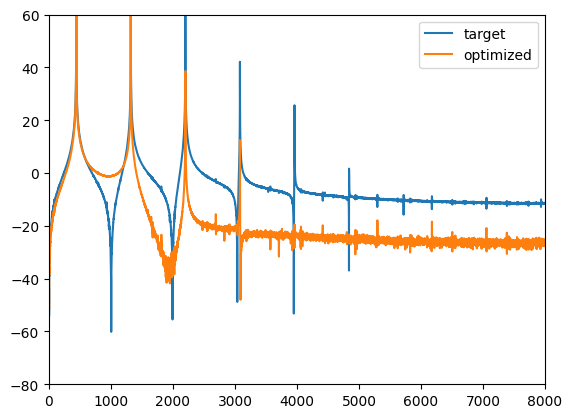

In [105]:
target_fft = torch.fft.rfft(test_audio)
opt_mod_matrix = make_mod_matrix(opt_mod_values)
optimized_audio = fm_renderer(f0, ratios, opt_levels, opt_mod_matrix, carrier_weights, Fs, duration)
opt_fft = torch.fft.rfft(optimized_audio)

peaks, _ = find_peaks(magnitudes, height=threshold_linear, distance=10)
print(len(peaks))

freqs_plot = np.fft.rfftfreq(len(test_audio), d=1/Fs)
plt.plot(freqs_plot, 20*np.log10(target_fft.abs().numpy() + 1e-8), label = 'target')
plt.plot(freqs_plot, 20*np.log10(opt_fft.detach().abs().numpy() + 1e-8), label = 'optimized')
plt.xlim(0, 8000)
plt.ylim(-80, 60)
plt.legend()
plt.show()